##### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import torchvision.datasets
from torchvision import transforms

import os
from tqdm import tqdm

##### Data sources

In [3]:
pets_path_train = './OxfordPets/train'
pets_path_test = './OxfordPets/test'
pets_train_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_train, split='trainval', target_types='binary-category', download=True)
pets_test_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_test, split='test', target_types='binary-category', download=True)

In [4]:
class_names = pets_train_orig.bin_classes
len(class_names)

2

In [5]:
class_names

['Cat', 'Dog']

In [6]:
pets_train_orig, pets_test_orig

(Dataset OxfordIIITPet
     Number of datapoints: 3680
     Root location: ./OxfordPets/train,
 Dataset OxfordIIITPet
     Number of datapoints: 3669
     Root location: ./OxfordPets/test)

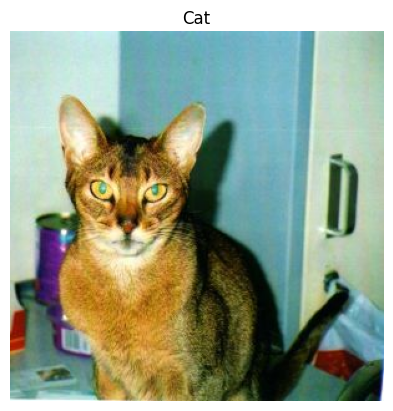

In [7]:
(train_pets_input, train_pets_target) = pets_train_orig[20]
plt.imshow(train_pets_input)
# plt.imshow(train_pets_input.permute(1,2,0).numpy())
plt.title(class_names[train_pets_target])
plt.axis('off')
plt.show()

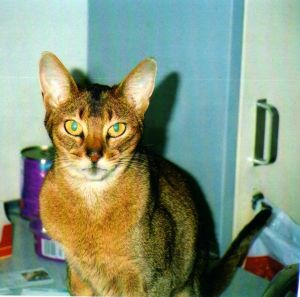

In [8]:
train_pets_input

In [9]:
train_pets_target

0

In [10]:
len(pets_train_orig), len(pets_test_orig)

(3680, 3669)

In [11]:
# Create a dataset wrapper that allows us to perform custom image augmentations
# on both the target and label (segmentation mask) images.
#
# These custom image augmentations are needed since we want to perform
# transforms such as:
# 1. Random horizontal flip
# 2. Image resize
#
# and these operations need to be applied consistently to both the input
# image as well as the segmentation mask.
class OxfordIIITPetsAugmented(torchvision.datasets.OxfordIIITPet):
    def __init__(
        self,
        root: str,
        split: str,
        # target_types="segmentation",
        # target_types="category",
        target_types="binary-category",
        download=False,
        pre_transform=None,
        post_transform=None,
        pre_target_transform=None,
        post_target_transform=None,
        common_transform=None,
    ):
        super().__init__(
            root=root,
            split=split,
            target_types=target_types,
            download=download,
            transform=pre_transform,
            # target_transform=pre_target_transform,
        )
        self.post_transform = post_transform
        # self.post_target_transform = post_target_transform
        self.common_transform = common_transform

    def __len__(self):
        return super().__len__()

    def __getitem__(self, idx):
        (input, target) = super().__getitem__(idx)
        
        # Common transforms are performed on both the input and the labels
        # by creating a 4 channel image and running the transform on both.
        # Then the segmentation mask (4th channel) is separated out.
        if self.common_transform is not None:
            # both = torch.cat([input, target], dim=0)
            # both = self.common_transform(both)
            # (input, target) = torch.split(both, 3, dim=0)
            input = self.common_transform(input)
        # end if
        
        if self.post_transform is not None:
            input = self.post_transform(input)
        # if self.post_target_transform is not None:
        #     target = self.post_target_transform(target)

        return (input, target)

In [12]:
def args_to_dict(**kwargs):
    return kwargs

transform_dict = args_to_dict(
    pre_transform=transforms.ToTensor(),
    pre_target_transform=transforms.ToTensor(),
    common_transform=transforms.Compose([
        # ToDevice(get_device()),
        # transforms.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
        # transforms.RandomResizedCrop(224),
        # transforms.Resize((224, 224), interpolation=T.InterpolationMode.NEAREST),
        transforms.Resize(224, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomCrop(224),
        # Random Horizontal Flip as data augmentation.
        transforms.RandomHorizontalFlip(p=0.5),
    ]),
    # post_transform=transforms.Compose([
        # Color Jitter as data augmentation.
        # transforms.ColorJitter(contrast=0.3),
    # ]),
    # post_target_transform=T.Compose([
    #     # T.Lambda(tensor_trimap),
    # ]),
)

In [13]:
pets_train = OxfordIIITPetsAugmented(
    root=pets_path_train,
    split="trainval",
    # target_types="segmentation",
    # target_types="category",
    target_types="binary-category",
    download=False,
    **transform_dict,
)

In [14]:
pets_test = OxfordIIITPetsAugmented(
    root=pets_path_test,
    split="test",
    # target_types="segmentation",
    # target_types="category",
    target_types="binary-category",
    download=False,
    **transform_dict,
)

In [15]:
pets_train, pets_test

(Dataset OxfordIIITPetsAugmented
     Number of datapoints: 3680
     Root location: ./OxfordPets/train
     StandardTransform
 Transform: ToTensor(),
 Dataset OxfordIIITPetsAugmented
     Number of datapoints: 3669
     Root location: ./OxfordPets/test
     StandardTransform
 Transform: ToTensor())

In [16]:
pets_train_loader = torch.utils.data.DataLoader(
    pets_train,
    # batch_size=64,
    batch_size=16,
    shuffle=True,
)

In [17]:
pets_test_loader = torch.utils.data.DataLoader(
    pets_test,
    batch_size=21,
    shuffle=True,
)

In [18]:
(train_pets_inputs, train_pets_targets) = next(iter(pets_train_loader))

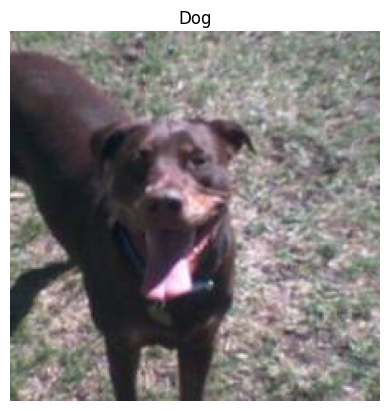

In [19]:
plt.imshow(train_pets_inputs[0].permute(1,2,0).numpy())
plt.axis('off')
plt.title(class_names[train_pets_targets[0]])
plt.show()

In [20]:
train_pets_targets

tensor([1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1])

In [21]:
def show_images(input_tensor, title=''):
    image = input_tensor.permute(1,2,0).numpy()
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()
    plt.pause(0.01)

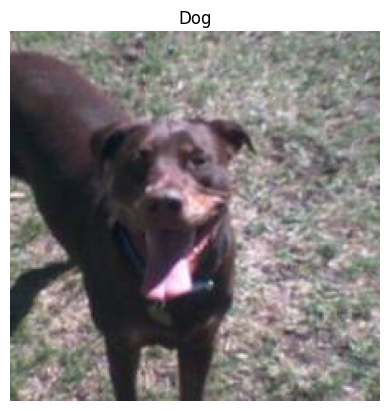

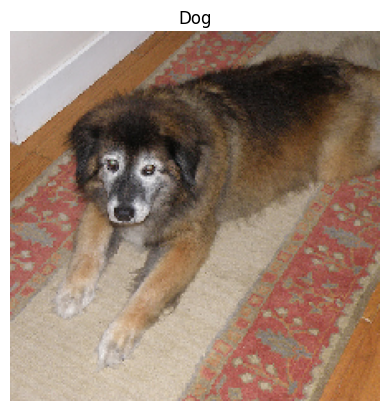

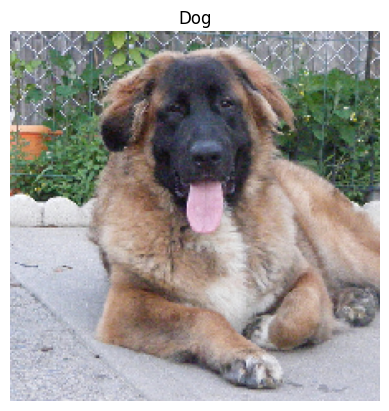

In [22]:
for i in range(len(train_pets_inputs)//5):
    show_images(train_pets_inputs[i], title=class_names[train_pets_targets[i]])

##### Save/load functions

In [23]:
def getdevice():
    if torch.cuda.is_available():
        return 'cuda'
    else:
        return 'cpu'

def savemodel(model, path):
    torch.save(model.state_dict(), path)

# def saveall(model, optimizer, loss, epoch, path):
def saveall(model, optimizer, epoch, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # 'loss': loss,
        'epoch': epoch
    }, path)

def loadmodel(model, path):
    # return model.load_state_dict(torch.load(path, map_location=getdevice()))
    # return model.load_state_dict(torch.load(path, weights_only=True))
    model.load_state_dict(torch.load(path, weights_only=True))

def loadall(model, optimizer, path):
    cp = torch.load(path, weights_only=True)
    model.load_state_dict(cp['model_state_dict'])
    optimizer.load_state_dict(cp['optimizer_state_dict'])
    # return cp['loss'], cp['epoch']
    return cp['epoch']


##### Neural net

In [24]:
class PetsNet(torch.nn.Module):
    def __init__(self):
        super(PetsNet, self).__init__()

        # pre-normalization
        self.bn0 = torch.nn.BatchNorm2d(num_features=3)

        # layer 1: 224x224x3
        self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, padding=1)
        self.act1 = torch.nn.ReLU()
        self.bn1 = torch.nn.BatchNorm2d(num_features=4)
        self.mp1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 2: 112x112x4
        self.conv2 = torch.nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1)
        self.act2 = torch.nn.ReLU()
        self.bn2 = torch.nn.BatchNorm2d(num_features=8)
        self.mp2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 3: 56x56x8
        self.conv3 = torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.act3 = torch.nn.ReLU()
        self.bn3 = torch.nn.BatchNorm2d(num_features=16)
        self.mp3 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 4: 28x28x16
        self.conv4 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.act4 = torch.nn.ReLU()
        self.bn4 = torch.nn.BatchNorm2d(num_features=32)
        self.mp4 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 5: 14x14x32
        self.conv5 = torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.act5 = torch.nn.ReLU()
        self.bn5 = torch.nn.BatchNorm2d(num_features=64)
        self.mp5 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 6: 7x7x64
        self.fc1 = torch.nn.Linear(7*7*64, 512)
        self.act6 = torch.nn.Tanh()
        self.bn6 = torch.nn.BatchNorm1d(num_features=512)

        # layer 7: 1x512
        self.fc2 = torch.nn.Linear(512, 128)
        self.act7 = torch.nn.Tanh()
        self.bn7 = torch.nn.BatchNorm1d(num_features=128)

        # layer 8: 1x128
        # self.fc3 = torch.nn.Linear(128, 37)
        self.fc3 = torch.nn.Linear(128, 2)

    def forward(self, x):
        x = self.bn0(x)

        x = self.conv1(x)
        x = self.act1(x)
        x = self.bn1(x)
        x = self.mp1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.bn2(x)
        x = self.mp2(x)

        x = self.conv3(x)
        x = self.act3(x)
        x = self.bn3(x)
        x = self.mp3(x)

        x = self.conv4(x)
        x = self.act4(x)
        x = self.bn4(x)
        x = self.mp4(x)

        x = self.conv5(x)
        x = self.act5(x)
        x = self.bn5(x)
        x = self.mp5(x)

        x = x.view(x.size(0), x.size(1)*x.size(2)*x.size(3))

        x = self.fc1(x)
        x = self.act6(x)
        x = self.bn6(x)

        x = self.fc2(x)
        x = self.act7(x)
        x = self.bn7(x)

        x = self.fc3(x)

        return x

##### Train/test functions

In [25]:
def train(model, optimizer, loss, train_dataloader, test_dataloader, passes=1):

    for epoch in range(passes):
        dltrain = train_dataloader
        dltest = test_dataloader

        running_loss = 0.
        running_acc = 0.

        model.train()
        for inputs, labels in tqdm(dltrain):
            optimizer.zero_grad()

            preds = model.forward(inputs)
            preds_class = preds.argmax(dim=1)

            loss_value = loss(preds, labels)
            loss_value.backward()

            optimizer.step()

            running_loss += loss_value.item()
            running_acc += (preds_class == labels.data).float().mean()

        epoch_train_loss = running_loss / len(dltrain)
        epoch_train_acc = running_acc / len(dltrain)

        running_loss = 0.
        running_acc = 0.

        model.eval()
        for inputs, labels in tqdm(dltest):
            preds = model.forward(inputs)
            preds_class = preds.argmax(dim=1)

            loss_value = loss(preds, labels)

            running_loss += loss_value.item()
            running_acc += (preds_class == labels.data).float().mean()

        epoch_test_loss = running_loss / len(dltest)
        epoch_test_acc = running_acc / len(dltest)

        print(f'Epoch: {epoch}')
        print(f'Train acc: {epoch_train_acc} Train loss: {epoch_train_loss}')
        print(f'Test acc: {epoch_test_acc} Test loss: {epoch_test_loss}')

In [26]:
def test(model, loss, test_dataloader):
    loss = torch.nn.CrossEntropyLoss()
    dltest = test_dataloader

    running_loss = 0.
    running_acc = 0.

    model.eval()
    for inputs, labels in tqdm(dltest):
        preds = model.forward(inputs)
        preds_class = preds.argmax(dim=1)

        loss_value = loss(preds, labels)

        running_loss += loss_value.item()
        running_acc += (preds_class == labels.data).float().mean()

    test_loss = running_loss / len(dltest)
    test_acc = running_acc / len(dltest)

    print(f'Acc: {test_acc} Loss: {test_loss}')

##### Training

In [27]:
net = PetsNet()

In [27]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

In [28]:
# pre test
test(net, loss, pets_test_loader)

100%|██████████| 175/175 [01:28<00:00,  1.99it/s]

Acc: 0.6772245764732361 Loss: 0.6853600379398891


In [29]:
# pass 1-5
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:37<00:00,  4.64it/s]


Epoch: 0
Train acc: 0.645108699798584 Train loss: 0.6489642915518388
Test acc: 0.6918092370033264 Test loss: 0.5781619043009621


100%|██████████| 175/175 [00:36<00:00,  4.80it/s]


Epoch: 1
Train acc: 0.679076075553894 Train loss: 0.5993633430937062
Test acc: 0.6971970796585083 Test loss: 0.5839790328911373


100%|██████████| 175/175 [00:35<00:00,  4.91it/s]


Epoch: 2
Train acc: 0.719021737575531 Train loss: 0.5569610359876053
Test acc: 0.7381765246391296 Test loss: 0.5247021291937147


100%|██████████| 175/175 [00:35<00:00,  4.88it/s]


Epoch: 3
Train acc: 0.731521725654602 Train loss: 0.5327063242378443
Test acc: 0.7560270428657532 Test loss: 0.5175362488201686


100%|██████████| 175/175 [00:37<00:00,  4.69it/s]

Epoch: 4
Train acc: 0.7551630139350891 Train loss: 0.5131467320996782
Test acc: 0.6907208561897278 Test loss: 0.5768212648800441


In [30]:
# net = PetsNet()
# optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
# loss = torch.nn.CrossEntropyLoss()
# epoch = loadall(model=net, optimizer=optimizer, path='./model.v1.pt')
# net.eval()
# print(epoch)

In [31]:
# test(model=net2, loss=loss, test_dataloader=pets_test_loader)

In [32]:
saveall(model=net, optimizer=optimizer, epoch=5, path='./model.v5.pt')

In [33]:
# pass 6-10
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:34<00:00,  5.04it/s]


Epoch: 0
Train acc: 0.7649456262588501 Train loss: 0.4960023038413214
Test acc: 0.7836188673973083 Test loss: 0.4685201271942684


100%|██████████| 175/175 [00:35<00:00,  5.00it/s]


Epoch: 1
Train acc: 0.7847825884819031 Train loss: 0.4793971703104351
Test acc: 0.7937955856323242 Test loss: 0.45735549977847506


100%|██████████| 175/175 [00:35<00:00,  4.93it/s]


Epoch: 2
Train acc: 0.7839673757553101 Train loss: 0.46600406914949416
Test acc: 0.8048973083496094 Test loss: 0.438437910250255


100%|██████████| 175/175 [00:35<00:00,  4.87it/s]


Epoch: 3
Train acc: 0.814402163028717 Train loss: 0.43333249007878094
Test acc: 0.7953191995620728 Test loss: 0.460216486624309


100%|██████████| 175/175 [00:35<00:00,  4.91it/s]

Epoch: 4
Train acc: 0.803260862827301 Train loss: 0.43234976419936055
Test acc: 0.8006524443626404 Test loss: 0.42795780088220325


In [34]:
saveall(model=net, optimizer=optimizer, epoch=10, path='./model.v10.pt')

In [35]:
savemodel(model=net, path='./model.pt')

In [28]:
net = PetsNet()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
loss = torch.nn.CrossEntropyLoss()
epoch = loadall(model=net, optimizer=optimizer, path='./model.v10.pt')
net.eval()
print(epoch)

10


In [29]:
# pass 11-15
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:46<00:00,  3.78it/s]


Epoch: 0
Train acc: 0.8171195387840271 Train loss: 0.40248062966958337
Test acc: 0.8151829242706299 Test loss: 0.42113755532673425


100%|██████████| 175/175 [01:55<00:00,  1.51it/s]


Epoch: 1
Train acc: 0.8277173638343811 Train loss: 0.3960548494173133
Test acc: 0.8137139081954956 Test loss: 0.41635704117161887


100%|██████████| 175/175 [00:41<00:00,  4.25it/s]


Epoch: 2
Train acc: 0.832336962223053 Train loss: 0.38377938688449237
Test acc: 0.8042990565299988 Test loss: 0.42910953862326484


100%|██████████| 175/175 [00:33<00:00,  5.15it/s]


Epoch: 3
Train acc: 0.835326075553894 Train loss: 0.37183645785502767
Test acc: 0.8131152987480164 Test loss: 0.4267198611157281


100%|██████████| 175/175 [00:42<00:00,  4.12it/s]

Epoch: 4
Train acc: 0.842119574546814 Train loss: 0.36516275567852935
Test acc: 0.8269926309585571 Test loss: 0.3913133948189872


In [31]:
saveall(model=net, optimizer=optimizer, epoch=15, path='./model.v15.pt')

In [32]:
# pass 16-20
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:45<00:00,  3.86it/s]


Epoch: 0
Train acc: 0.845652163028717 Train loss: 0.3538688420601513
Test acc: 0.8296593427658081 Test loss: 0.3902114175898688


100%|██████████| 175/175 [00:43<00:00,  4.07it/s]


Epoch: 1
Train acc: 0.8600543737411499 Train loss: 0.3370115379276483
Test acc: 0.8395097851753235 Test loss: 0.3803935223392078


100%|██████████| 175/175 [00:40<00:00,  4.36it/s]


Epoch: 2
Train acc: 0.8508152365684509 Train loss: 0.34000245818625324
Test acc: 0.8328158855438232 Test loss: 0.3846519151329994


100%|██████████| 175/175 [00:39<00:00,  4.43it/s]


Epoch: 3
Train acc: 0.864673912525177 Train loss: 0.31963887464093127
Test acc: 0.8397818207740784 Test loss: 0.4058022556134633


100%|██████████| 175/175 [00:39<00:00,  4.47it/s]

Epoch: 4
Train acc: 0.863043487071991 Train loss: 0.32655706140010254
Test acc: 0.8244891166687012 Test loss: 0.39584925562143325


In [33]:
saveall(model=net, optimizer=optimizer, epoch=20, path='./model.v20.pt')

In [34]:
savemodel(model=net, path='./model.pt')

In [35]:
# pass 21-25
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:41<00:00,  4.19it/s]


Epoch: 0
Train acc: 0.8687499761581421 Train loss: 0.3119360856063988
Test acc: 0.8358091711997986 Test loss: 0.3601981642842293


100%|██████████| 175/175 [01:05<00:00,  2.66it/s]


Epoch: 1
Train acc: 0.8706521987915039 Train loss: 0.2989572766844345
Test acc: 0.8383122682571411 Test loss: 0.3695038138968604


100%|██████████| 175/175 [01:03<00:00,  2.74it/s]


Epoch: 2
Train acc: 0.8785325884819031 Train loss: 0.29393467190472977
Test acc: 0.8430472016334534 Test loss: 0.3723549754704748


100%|██████████| 175/175 [00:39<00:00,  4.46it/s]


Epoch: 3
Train acc: 0.8673912882804871 Train loss: 0.2973150355498428
Test acc: 0.8369519114494324 Test loss: 0.37237652838230134


100%|██████████| 175/175 [00:41<00:00,  4.25it/s]

Epoch: 4
Train acc: 0.8706521987915039 Train loss: 0.29373180164915064
Test acc: 0.8511013388633728 Test loss: 0.3482860312291554


In [36]:
saveall(model=net, optimizer=optimizer, epoch=25, path='./model.v25.pt')

In [37]:
savemodel(model=net, path='./model.pt')

In [38]:
# pass 25-30
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:33<00:00,  5.22it/s]


Epoch: 0
Train acc: 0.876630425453186 Train loss: 0.2939971121918896
Test acc: 0.8401083946228027 Test loss: 0.3739671516418457


100%|██████████| 175/175 [00:34<00:00,  5.11it/s]


Epoch: 1
Train acc: 0.8902173638343811 Train loss: 0.2613309705225022
Test acc: 0.8544754385948181 Test loss: 0.360454822906426


100%|██████████| 175/175 [00:34<00:00,  5.01it/s]


Epoch: 2
Train acc: 0.8910326361656189 Train loss: 0.2666566297897826
Test acc: 0.8591014742851257 Test loss: 0.32869996085762976


100%|██████████| 175/175 [01:13<00:00,  2.37it/s]


Epoch: 3
Train acc: 0.8826087117195129 Train loss: 0.2723845723854459
Test acc: 0.8428835868835449 Test loss: 0.3659471908956766


100%|██████████| 175/175 [00:34<00:00,  5.10it/s]

Epoch: 4
Train acc: 0.895923912525177 Train loss: 0.25861856274954653
Test acc: 0.8460404872894287 Test loss: 0.358090492444379


In [39]:
saveall(model=net, optimizer=optimizer, epoch=30, path='./model.v30.pt')

In [40]:
savemodel(model=net, path='./model.pt')